## Results

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
from mindmetrix_biomarker.loader import load_data
from mindmetrix_biomarker.preprocess import preprocess_physiological_data, preprocess_subjects_data, check_subjects_in_datasets
from mindmetrix_biomarker.exctract import extract_features

In [ ]:
# Load and preprocess data
data_path = Path("../data/raw/timeseries.csv")
physiological_df = load_data(data_path)
preprocessed_physiological_df = preprocess_physiological_data(physiological_df)
subjects_data_path = Path("../data/raw/subjects.csv")
subjects_df = load_data(subjects_data_path)
preprocessed_subjects_df = preprocess_subjects_data(subjects_df)
missing_in_physiological, missing_in_subjects = check_subjects_in_datasets(preprocessed_physiological_df, preprocessed_subjects_df)
preprocessed_subjects_df = preprocessed_subjects_df[~preprocessed_subjects_df["SubjectID"].isin(missing_in_physiological)]
preprocessed_physiological_df = preprocessed_physiological_df[~preprocessed_physiological_df["SubjectID"].isin(missing_in_subjects)]
# Extract features
all_features = extract_features(preprocessed_physiological_df, preprocessed_subjects_df)


Preprocessing physiological data...
Validating data schema...
Delete duplicates done.
Delete implausible values and low quality signals done.
Filter by angles done.
Preprocessing physiological data done.
Preprocessing subjects data...
Delete duplicates done.
Preprocessing subjects data done.
Extracting features...
Features extracted successfully.


In [3]:
# Number of features extracted
print(f"Total number of features: {all_features.shape[1]}")

Total number of features: 97


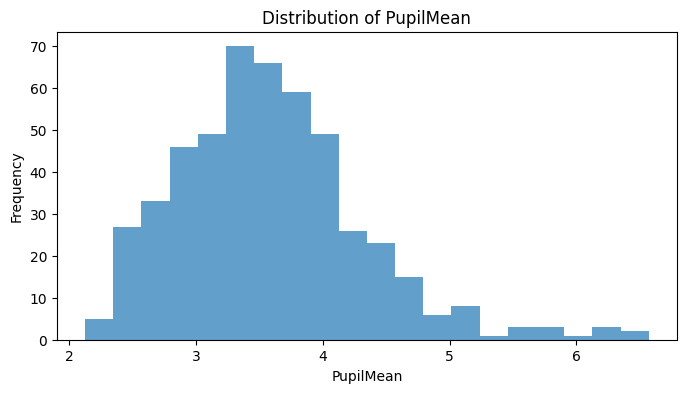

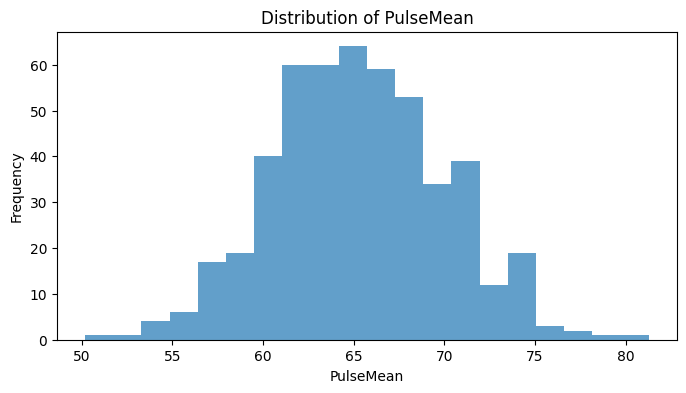

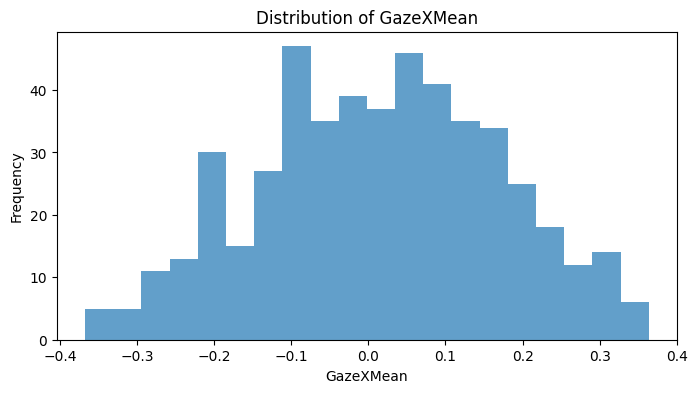

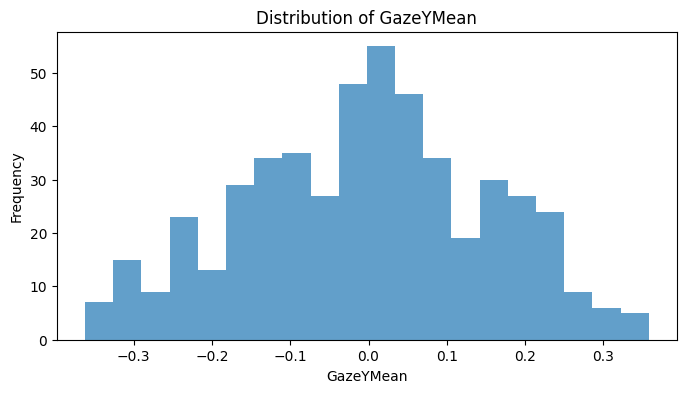

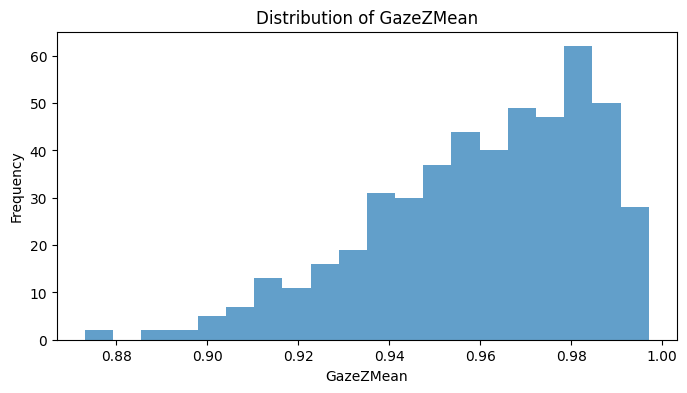

In [4]:
# Visualize distribution of a few key features
key_features = ["PupilMean", "PulseMean", "GazeXMean", "GazeYMean", "GazeZMean"]
for feature in key_features:
    plt.figure(figsize=(8, 4))
    plt.hist(all_features[feature], bins=20, alpha=0.7)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

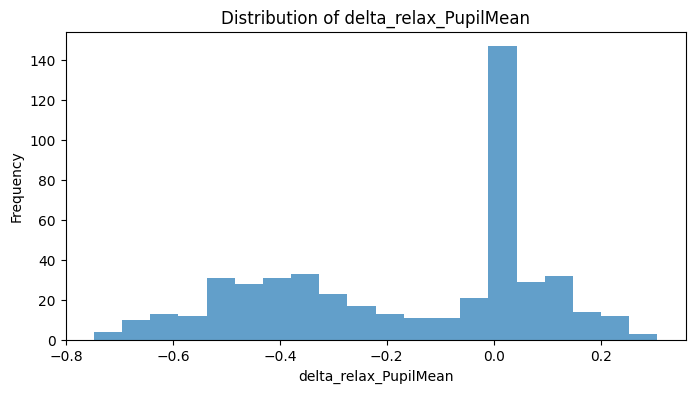

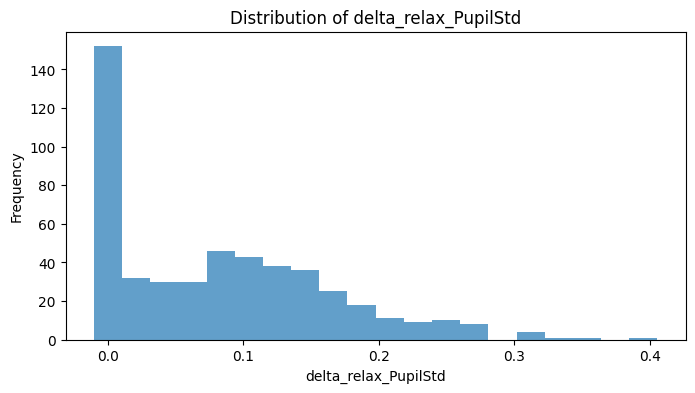

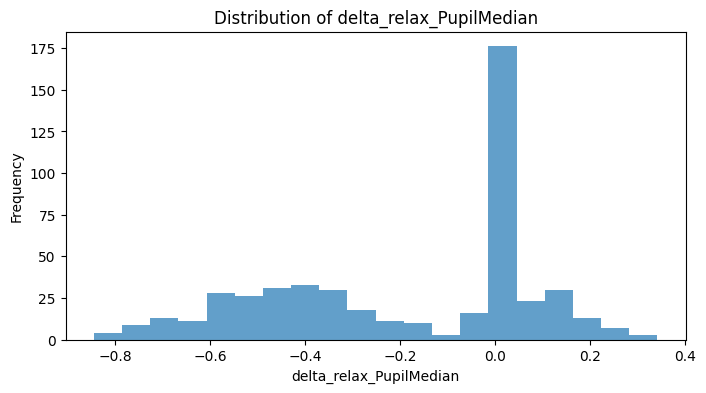

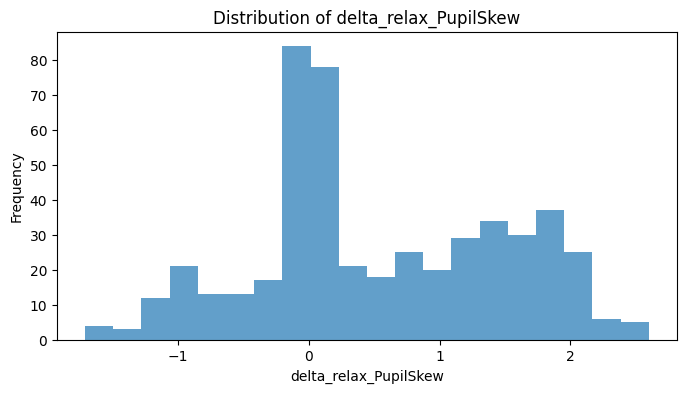

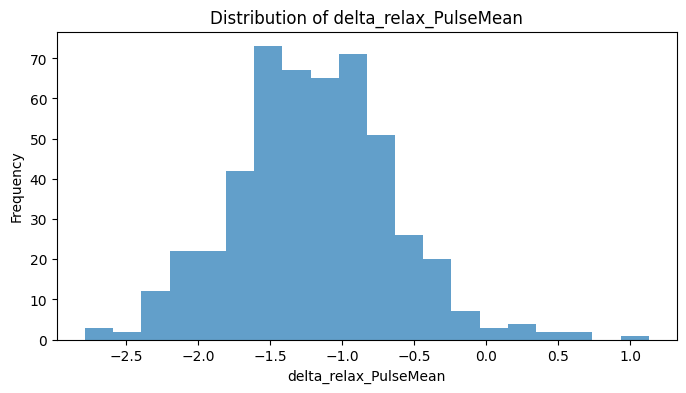

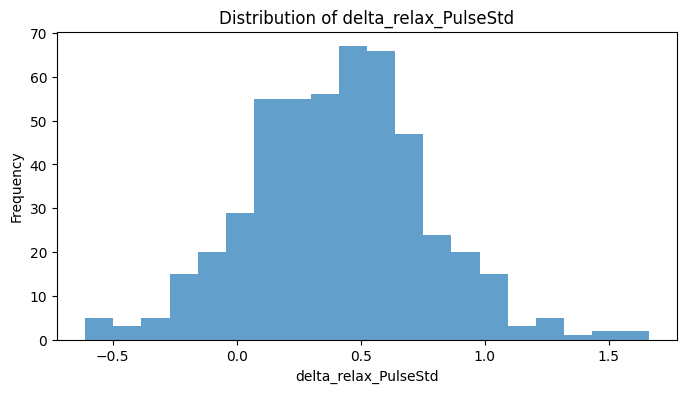

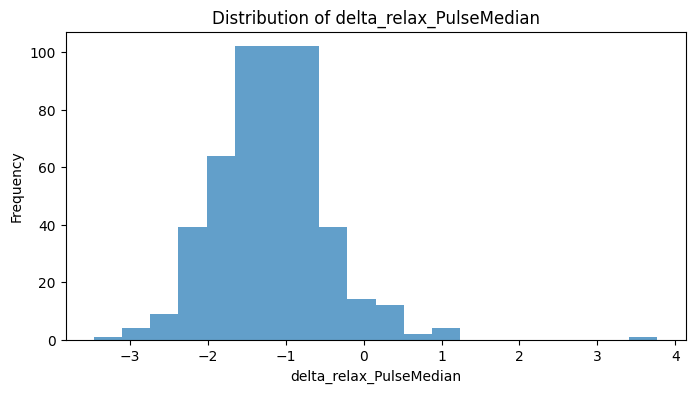

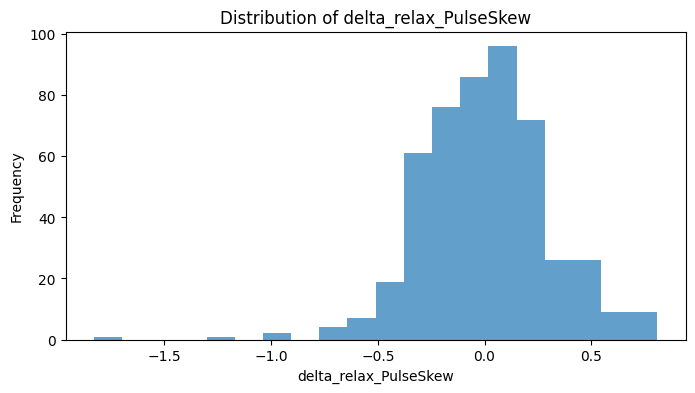

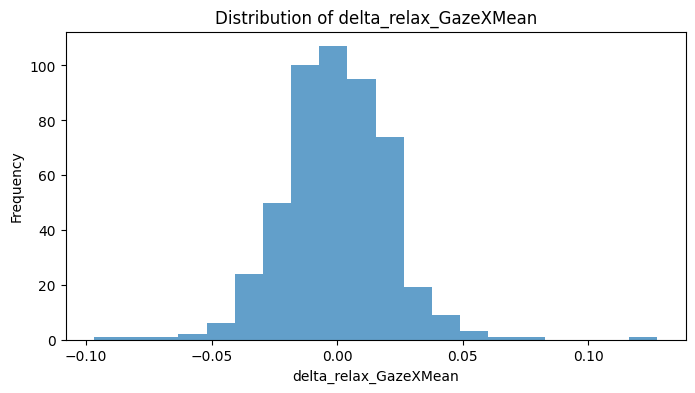

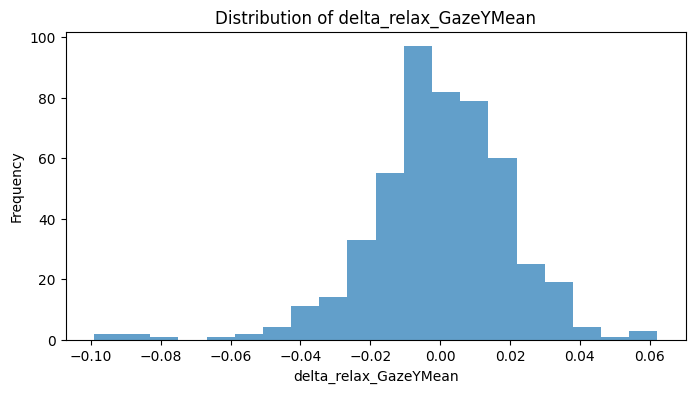

In [5]:
# Visualize the distribution of delta features
delta_features = [col for col in all_features.columns if "delta" in col]
for feature in delta_features[:10]:
    plt.figure(figsize=(8, 4))
    plt.hist(all_features[feature], bins=20, alpha=0.7)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

##### Hp1: Different pupil diameter, pulse and gaze correlate with subject stress (STAI)

In [6]:
numeric_feats = all_features.select_dtypes(include=np.number).drop(
    columns=["STAI_T", "STAI_S", "WearsGlasses", "CalibrationError"], errors="ignore"
)

corr_with_stai = pd.DataFrame({
    "corr_STAI_T": numeric_feats.corrwith(all_features["STAI_T"]),
    "corr_STAI_S": numeric_feats.corrwith(all_features["STAI_S"]),
}).dropna().sort_values("corr_STAI_T", key=abs, ascending=False)

corr_with_stai

,corr_STAI_T,corr_STAI_S
delta_break_PupilMedian,0.395968,0.326672
delta_break_PupilMean,0.395121,0.325775
delta_relax_PupilMedian,0.383572,0.314232
delta_relax_PupilMean,0.380668,0.308944
delta_relax_PupilSkew,-0.323480,-0.265621
...,...,...
deltapop_break_GazeYMean,-0.003977,0.000688
deltapop_baseline_GazeXStd,0.003972,0.017735
PulseIQR,0.001363,0.012010
deltapop_baseline_PulseSkew,-0.000772,0.008693


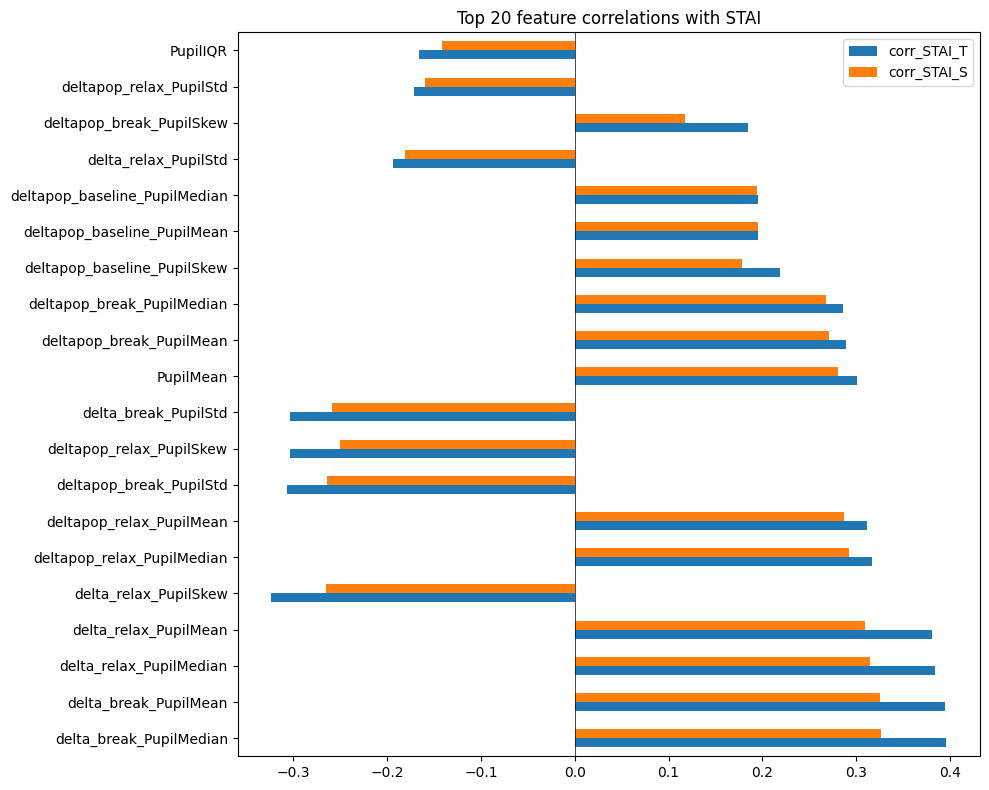

In [7]:
# Top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
corr_with_stai.head(20).plot.barh(ax=ax)
ax.set_title("Top 20 feature correlations with STAI")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### Sensitivity test

In [8]:
# Select candidate biomarkers to state the correlation with STAI-T
biomarkers_correlation = corr_with_stai.sort_values("corr_STAI_T", key=abs, ascending=False)["corr_STAI_T"]
print("Top biomarker candidates for STAI-T:")
print(biomarkers_correlation[biomarkers_correlation > 0.3])

Top biomarker candidates for STAI-T:
delta_break_PupilMedian       0.395968
delta_break_PupilMean         0.395121
delta_relax_PupilMedian       0.383572
delta_relax_PupilMean         0.380668
deltapop_relax_PupilMedian    0.317238
deltapop_relax_PupilMean      0.311125
PupilMean                     0.301164
Name: corr_STAI_T, dtype: float64


In [9]:
top_biomarkers = biomarkers_correlation[biomarkers_correlation > 0.3]
print("Top biomarker candidates for STAI-T:")
print(top_biomarkers.index.tolist())

Top biomarker candidates for STAI-T:
['delta_break_PupilMedian', 'delta_break_PupilMean', 'delta_relax_PupilMedian', 'delta_relax_PupilMean', 'deltapop_relax_PupilMedian', 'deltapop_relax_PupilMean', 'PupilMean']


In [10]:
# Correlation with STAI for lower stress group
low_stress = all_features[all_features["STAI_T"] < 40]
high_stress = all_features[all_features["STAI_T"] >= 40]
print(f"Low stress group: {len(low_stress)} subjects, mean STAI_T: {low_stress['STAI_T'].mean():.2f}")
print(f"High stress group: {len(high_stress)} subjects, mean STAI_T: {high_stress['STAI_T'].mean():.2f}")



print(f"{'Biomarker':<40} {'t-stat':>8} {'p-value':>10} {'Difference?':>12}")
print("-" * 82)

for col in top_biomarkers.index.to_list():
    if col not in all_features.columns:
        continue
    low_vals = low_stress[col].dropna()
    high_vals = high_stress[col].dropna()
    if len(low_vals) < 5 or len(high_vals) < 5:
        continue
    t_stat, p_val = stats.ttest_ind(low_vals, high_vals)
    difference = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<40} {t_stat:>8.3f} {p_val:>10.4f} {difference:>12}")

Low stress group: 295 subjects, mean STAI_T: 31.16
High stress group: 200 subjects, mean STAI_T: 54.01
Biomarker                                  t-stat    p-value  Difference?
----------------------------------------------------------------------------------
delta_break_PupilMedian                   -10.054     0.0000          Yes
delta_break_PupilMean                     -10.024     0.0000          Yes
delta_relax_PupilMedian                    -9.530     0.0000          Yes
delta_relax_PupilMean                      -9.623     0.0000          Yes
deltapop_relax_PupilMedian                 -6.114     0.0000          Yes
deltapop_relax_PupilMean                   -5.969     0.0000          Yes
PupilMean                                  -5.675     0.0000          Yes


#### Hp2: Lower stress subjects (low STAI) are more sensitive to the relaxation over phases?

In [11]:
# Lower stress subjects (STAI_T < 40) are more reactive to changes over relaxation phases?

print(f"{'Biomarker':<40} {'t-stat':>8} {'p-value':>10} {'Difference?':>12}")
print("-" * 82)
delta_features = all_features.filter(regex="^(delta|deltapop)")

reactivity_biomarkers = delta_features.columns.tolist()

for col in reactivity_biomarkers:
    if col not in all_features.columns:
        continue
    low_vals = low_stress[col].dropna()
    high_vals = high_stress[col].dropna()
    if len(low_vals) < 5 or len(high_vals) < 5:
        continue
    t_stat, p_val = stats.ttest_ind(low_vals, high_vals)
    difference = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<40} {t_stat:>8.3f} {p_val:>10.4f} {difference:>12}")

Biomarker                                  t-stat    p-value  Difference?
----------------------------------------------------------------------------------
delta_relax_PupilMean                      -9.623     0.0000          Yes
delta_relax_PupilStd                        4.727     0.0000          Yes
delta_relax_PupilMedian                    -9.530     0.0000          Yes
delta_relax_PupilSkew                       7.691     0.0000          Yes
delta_relax_PulseMean                       1.241     0.2150           No
delta_relax_PulseStd                        0.484     0.6287           No
delta_relax_PulseMedian                     1.789     0.0743           No
delta_relax_PulseSkew                      -1.228     0.2199           No
delta_relax_GazeXMean                      -0.872     0.3837           No
delta_relax_GazeYMean                      -0.045     0.9640           No
delta_relax_GazeZMean                       1.198     0.2316           No
delta_relax_GazeXStd         

#### Hp3: Lower stress subjects (low STAI) are more sensitive over cycles

In [12]:
# Lower stress subjects (STAI_T < 40) are more reactive to changes over cycles?
print(f"{'Biomarker':<40} {'t-stat':>8} {'p-value':>10} {'Difference?':>12}")
print("-" * 82)
adaption_biomarkers = [
    "PupilSlope",
    "PulseSlope",
    "GazeXSlope",
    "GazeYSlope",
    "GazeZSlope",
]
for col in adaption_biomarkers:
    if col not in all_features.columns:
        continue
    low_vals = low_stress[col].dropna()
    high_vals = high_stress[col].dropna()
    if len(low_vals) < 5 or len(high_vals) < 5:
        continue
    t_stat, p_val = stats.ttest_ind(low_vals, high_vals)
    difference = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<40} {t_stat:>8.3f} {p_val:>10.4f} {difference:>12}")

Biomarker                                  t-stat    p-value  Difference?
----------------------------------------------------------------------------------
PupilSlope                                  0.617     0.5373           No
PulseSlope                                  1.158     0.2474           No
GazeXSlope                                  0.125     0.9003           No
GazeYSlope                                  0.484     0.6288           No
GazeZSlope                                  1.132     0.2583           No
